fastival Sales data EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv('FastivalSalesData.csv', encoding='cp1252')
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [8]:
df.shape

(11251, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [ ]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [23]:
df.drop(['User_ID'], axis=1, inplace=True)           

In [11]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [12]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [13]:
df.shape

(11251, 13)

In [15]:
# Drop rows with missing values
df.dropna(inplace=True)
df.shape

(11239, 13)

In [16]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [19]:
# chaning datatypes
df["Amount"] = df["Amount"].astype(int)
df["Amount"].dtype

dtype('int64')

In [24]:
df.columns

Index(['Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age', 'married',
       'State', 'Zone', 'Occupation', 'Product_Category', 'Orders',
       'SalesAmount'],
      dtype='object')

In [21]:
# column name change
df.rename(columns={'Amount':'SalesAmount', 'Marital_Status':'married' }, inplace=True)
df.columns


Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'married', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders',
       'SalesAmount'],
      dtype='object')

In [25]:
# statistical summary
df.describe()

,Age,married,Orders,SalesAmount
count,11239.000000,11239.000000,11239.000000,11239.000000
mean,35.410357,0.420055,2.489634,9453.610553
std,12.753866,0.493589,1.114967,5222.355168
min,12.000000,0.000000,1.000000,188.000000
25%,27.000000,0.000000,2.000000,5443.000000
50%,33.000000,0.000000,2.000000,8109.000000
75%,43.000000,1.000000,3.000000,12675.000000
max,92.000000,1.000000,4.000000,23952.000000


In [26]:
# statical summary of for specific column
df[['Age', 'Orders', 'SalesAmount']].describe()

,Age,Orders,SalesAmount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


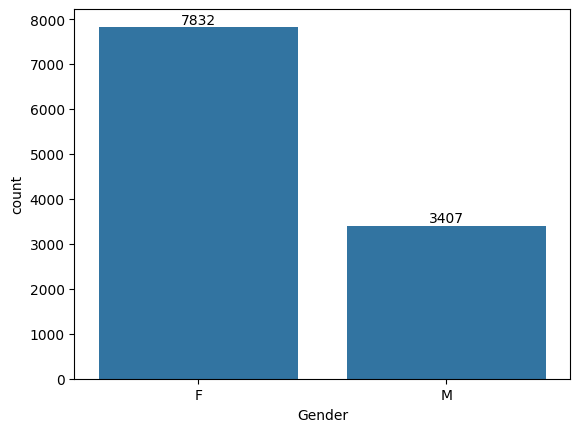

In [30]:
# count plot for gender with count labels
ax= sns.countplot(df, x='Gender')
for bar in ax.containers:
    ax.bar_label(bar)

In [34]:
# total sales amount
total_sales = df['SalesAmount'].sum()
print("Total Sales Amount:", total_sales)

Total Sales Amount: 106249129


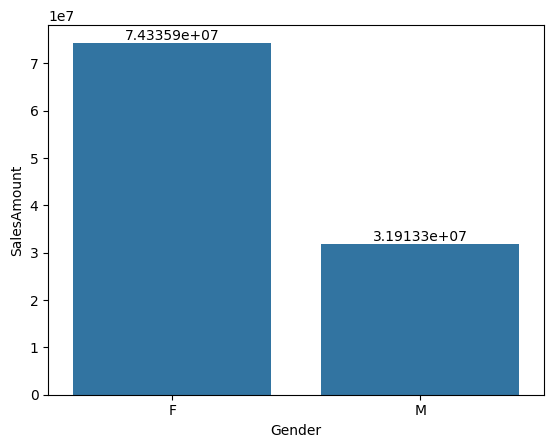

In [35]:
sale_gen= df.groupby(['Gender'], 
                    as_index=False)['SalesAmount'].sum().sort_values(by='SalesAmount', ascending=False)
# bar plot for Gender and SalesAmount with labels
ax = sns.barplot(data=sale_gen, x='Gender', y='SalesAmount')
for bar in ax.containers:
    ax.bar_label(bar)

    

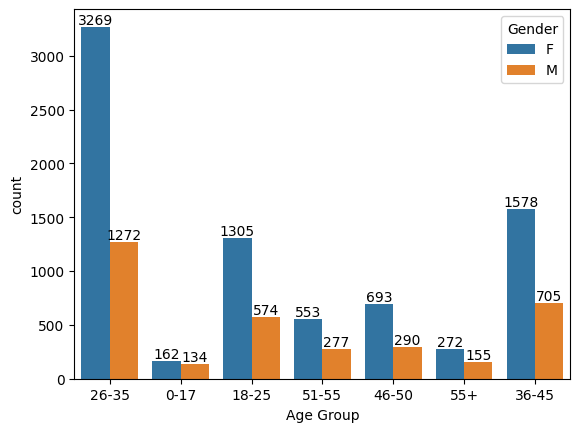

In [39]:
# countplot for age group
ax = sns.countplot(df, x='Age Group', hue='Gender' )
for bar in ax.containers:
    ax.bar_label(bar)

<Axes: xlabel='Age Group', ylabel='SalesAmount'>

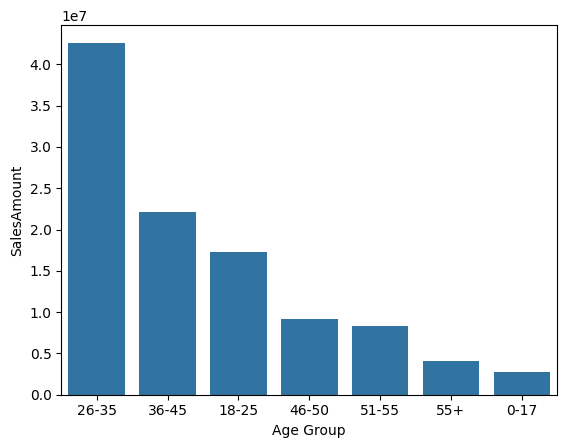

In [42]:
sale_age= df.groupby(['Age Group'], 
                  as_index=False)['SalesAmount'].sum().sort_values(by='SalesAmount', ascending=False)

sns.barplot(data=sale_age, x='Age Group', y='SalesAmount')

<Axes: xlabel='State', ylabel='Orders'>

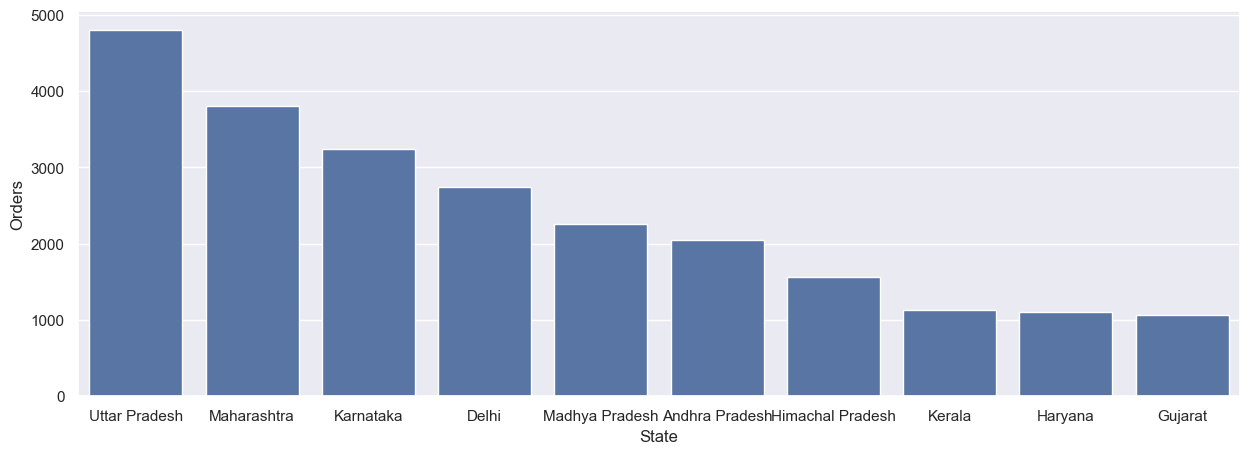

In [50]:
# Top 10 orders by states
states_order = df.groupby('State', as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
# set figure size for x axis labels
sns.set_theme(rc={'figure.figsize':(15,5)})
sns.barplot(data=states_order, x='State', y='Orders')

<Axes: xlabel='State', ylabel='SalesAmount'>

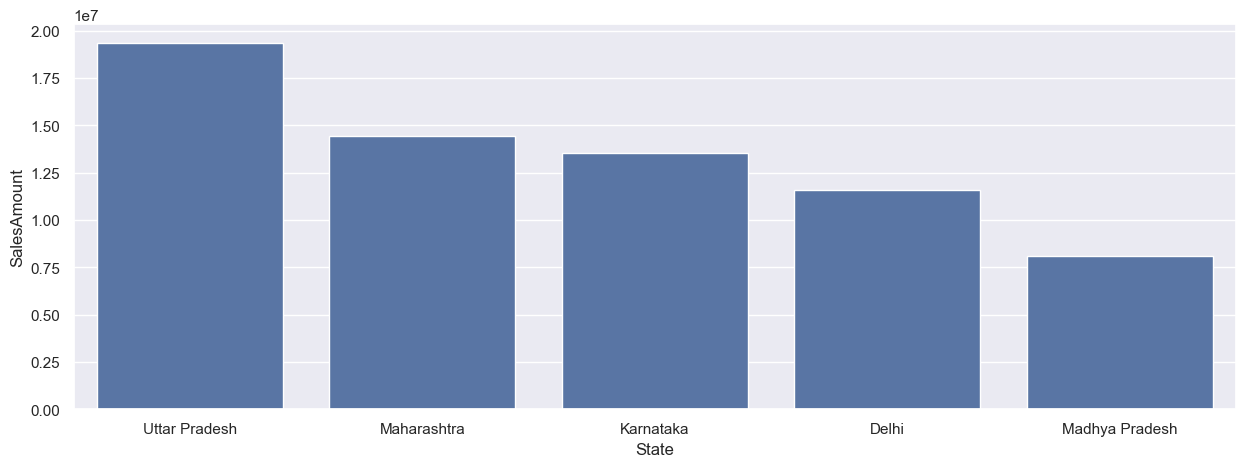

In [51]:
# Top 5 states by sales amount
states_sale = df.groupby('State', as_index=False)['SalesAmount'].sum().sort_values(by='SalesAmount', ascending=False).head(5)
# set figure size for x axis labels
sns.set_theme(rc={'figure.figsize':(15,5)})
sns.barplot(data=states_sale, x='State', y='SalesAmount')

In [52]:
df.columns

Index(['Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age', 'married',
       'State', 'Zone', 'Occupation', 'Product_Category', 'Orders',
       'SalesAmount'],
      dtype='object')

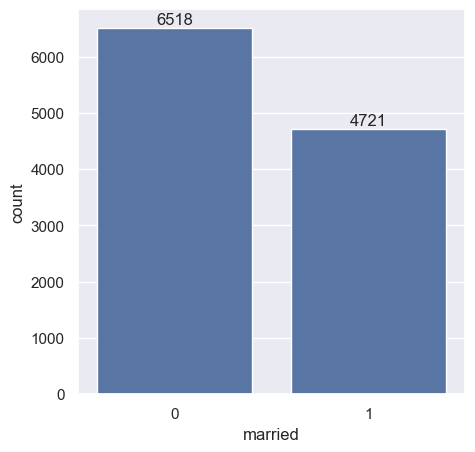

In [59]:
# bar plot for marital status with count labels
ax = sns.countplot(df, x='married')
sns.set_theme(rc={'figure.figsize':(7,5)})

for bar in ax.containers:
    ax.bar_label(bar)
    

<Axes: xlabel='married', ylabel='SalesAmount'>

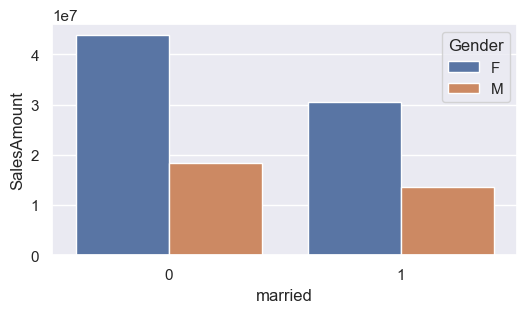

In [62]:
# sales by marital status and gender

sale_married = df.groupby(['married', 'Gender'], as_index=False)['SalesAmount'].sum().sort_values(by='SalesAmount', ascending=False)
sns.set_theme(rc={'figure.figsize':(6,3)})
sns.barplot(data=sale_married, x='married', y='SalesAmount',    hue='Gender')

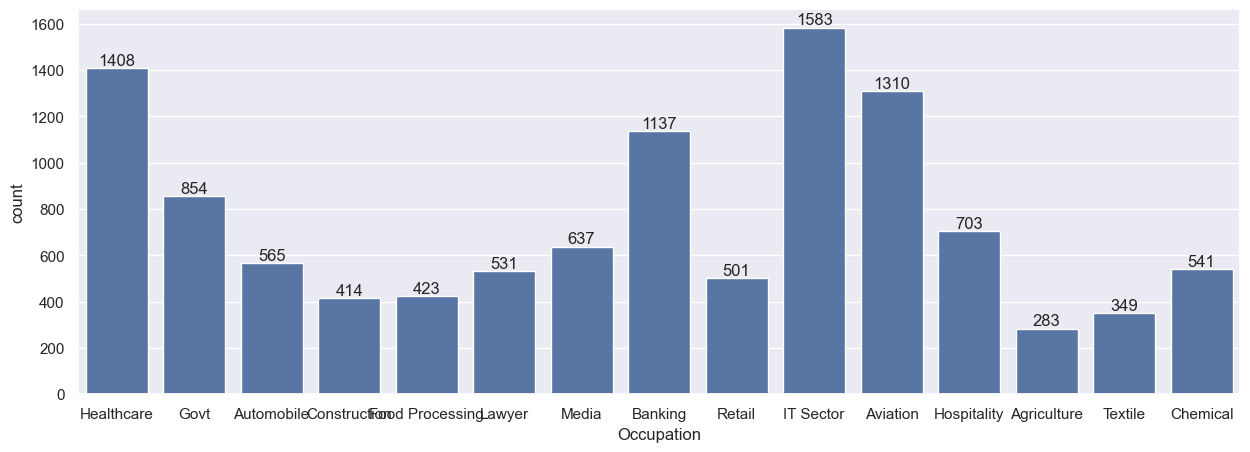

In [63]:
# bar plot for occupation with count labels
sns.set_theme(rc={'figure.figsize':(15,5)})
ax = sns.countplot(df, x='Occupation')
for bar in ax.containers:
    ax.bar_label(bar)


<Axes: xlabel='Occupation', ylabel='SalesAmount'>

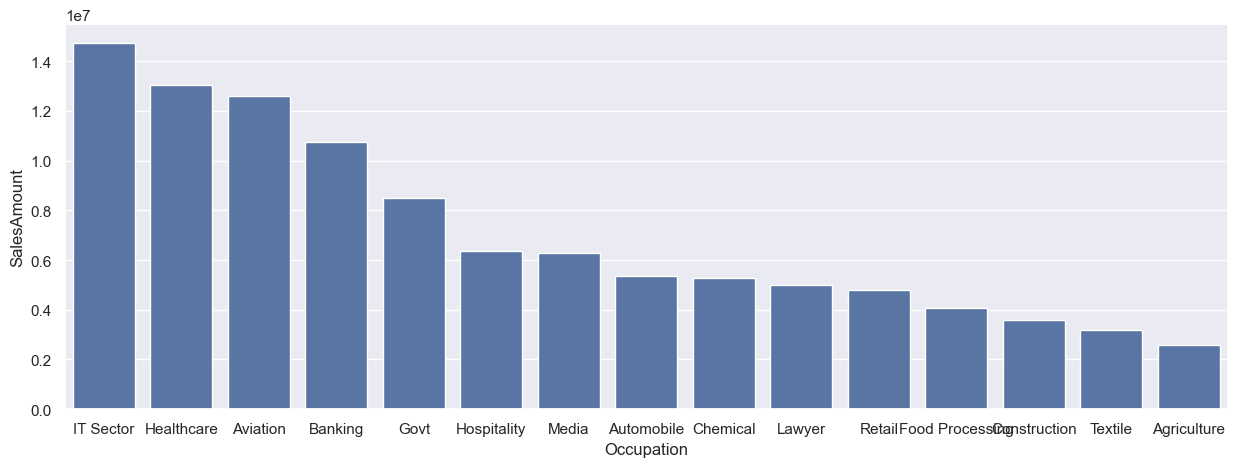

In [64]:
# sales by occupation
sale_occupation = df.groupby(['Occupation'], as_index=False)['SalesAmount'].sum().sort_values(by='SalesAmount', ascending=False)
sns.barplot(data=sale_occupation, x='Occupation', y='SalesAmount')

    

In [65]:
top_occupation = sale_occupation.iloc[0]['Occupation']
top_sales = sale_occupation.iloc[0]['SalesAmount']
print(f"The occupation with the highest sales is {top_occupation} with {top_sales} sales.")

The occupation with the highest sales is IT Sector with 14755079 sales.


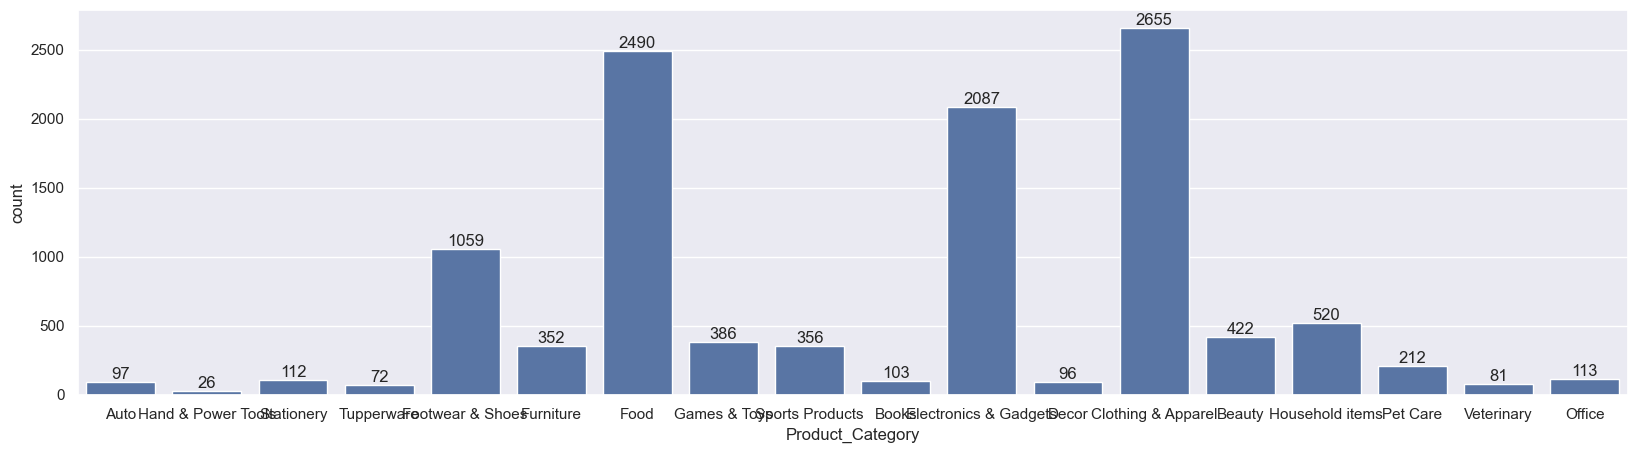

In [67]:
# product category with bar plot and count labels
sns.set_theme(rc={'figure.figsize':(20,5)}) 
ax = sns.countplot(df, x='Product_Category')
for bar in ax.containers:
    ax.bar_label(bar)


<Axes: xlabel='Product_Category', ylabel='SalesAmount'>

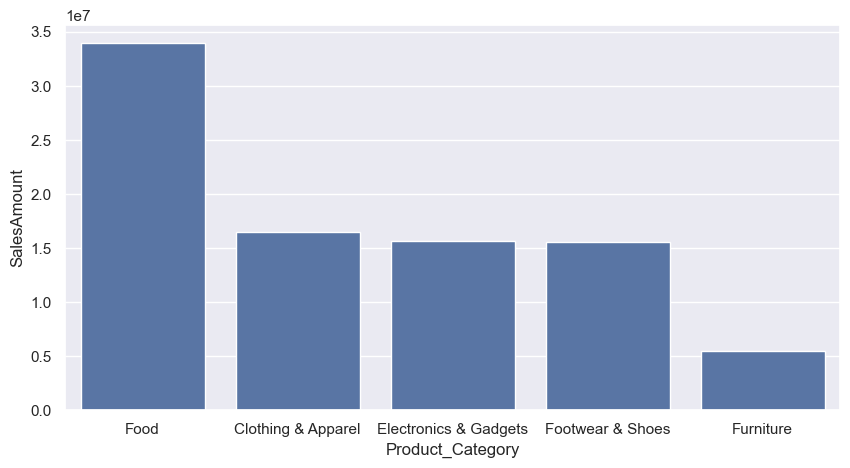

In [70]:
# top 5 product category by sales amount by bar plot
sale_product = df.groupby('Product_Category', as_index=False)['SalesAmount'].sum().sort_values(by='SalesAmount', ascending=False).head(5)
sns.set_theme(rc={'figure.figsize':(10,5)})
sns.barplot(data=sale_product, x='Product_Category', y='SalesAmount')


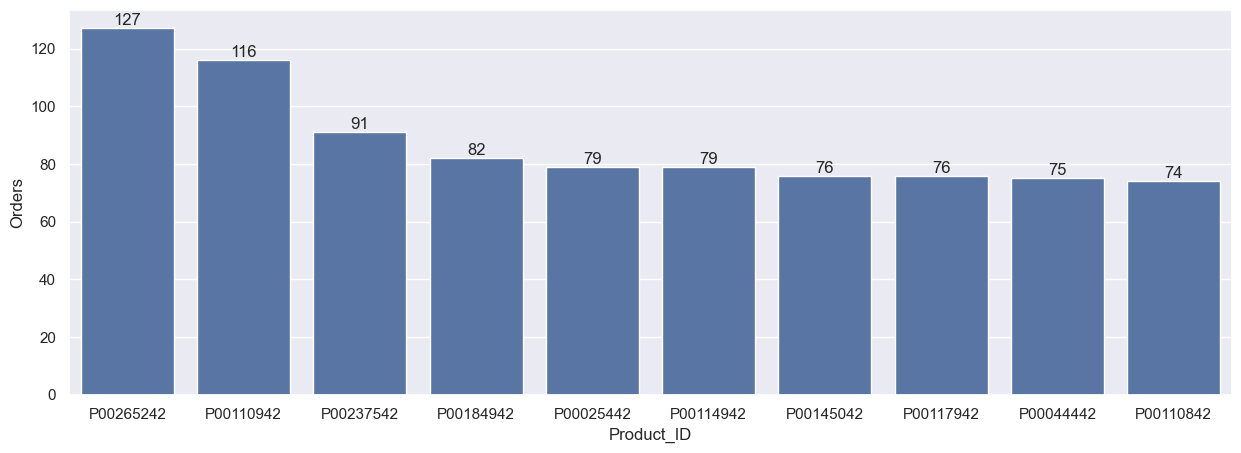

In [74]:
# top 10 product id by orders in bar plot with lables
product_order = df.groupby('Product_ID', as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
sns.set_theme(rc={'figure.figsize':(15,5)})
ax=sns.barplot(data=product_order, x='Product_ID', y='Orders')
for bar in ax.containers:
    ax.bar_label(bar)